CSV files found:
/kaggle/input/datasets/angeldaher/archive-1/netflix_titles.csv

Dataset loaded successfully!
File used: /kaggle/input/datasets/angeldaher/archive-1/netflix_titles.csv

=== PROJECT OBJECTIVE ===
In this project, I explore Netflix content to understand how movies and TV shows are distributed over time and across countries.

=== DATASET PREVIEW ===


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



=== DATASET INFORMATION ===
Rows: 8807
Columns: 12

Column names:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

=== BASIC ANALYSIS ===
Movies: 6131
TV Shows: 2676
Observation: Netflix contains more movies than TV shows in this dataset.


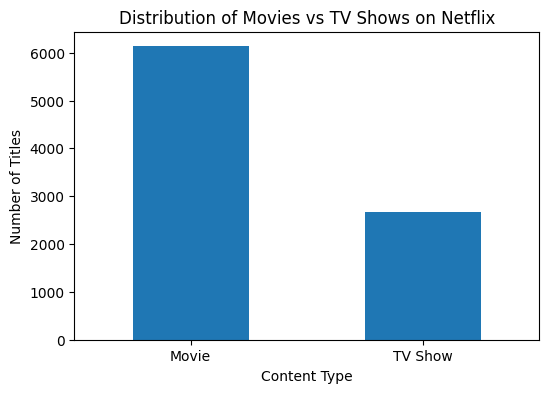


=== CONTENT OVER TIME ===


release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

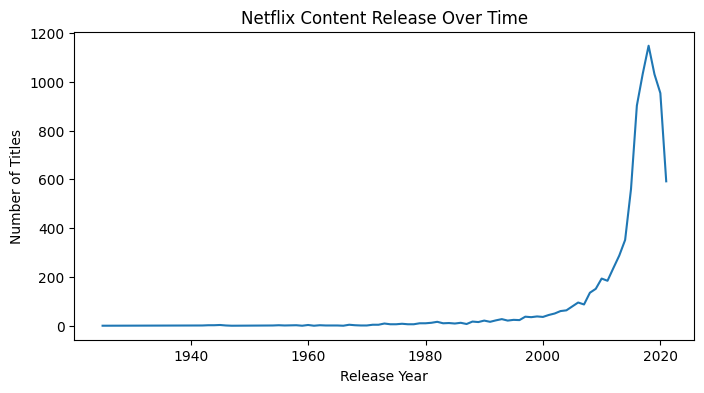


=== TOP COUNTRIES ===


country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

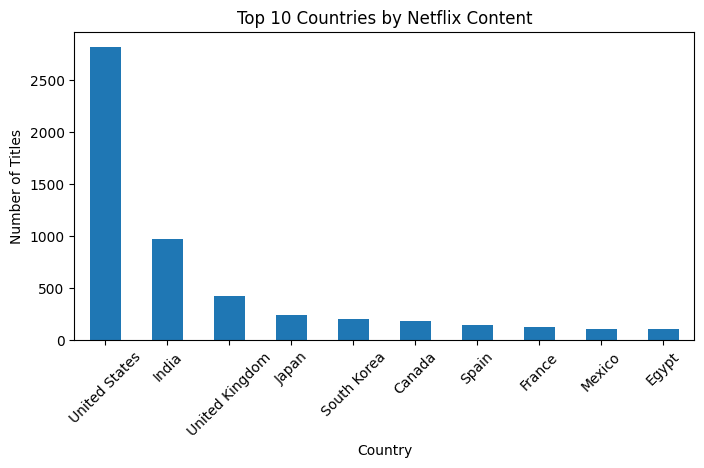


=== FINAL INTERPRETATION ===
The dataset shows that Netflix contains more movies than TV shows.
The number of released titles increased strongly in recent years, reflecting the growth of streaming platforms.
The United States appears as one of the leading content-producing countries in the Netflix catalog.
This project demonstrates basic data cleaning, exploratory analysis, visualization, and interpretation using Python.


In [7]:
# ==========================================
# NETFLIX CONTENT ANALYSIS PROJECT
# Angel Daher
# ==========================================

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# 1. Automatically find CSV file
csv_files = glob.glob("/kaggle/input/**/*.csv", recursive=True)

print("CSV files found:")
for file in csv_files:
    print(file)

# Load the first CSV found
file_path = csv_files[0]
df = pd.read_csv(file_path)

print("\nDataset loaded successfully!")
print("File used:", file_path)

# 2. Project Objective
print("\n=== PROJECT OBJECTIVE ===")
print("In this project, I explore Netflix content to understand how movies and TV shows are distributed over time and across countries.")

# 3. Dataset Preview
print("\n=== DATASET PREVIEW ===")
display(df.head())

# 4. Basic Dataset Info
print("\n=== DATASET INFORMATION ===")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns)

# 5. Basic Cleaning
df = df.dropna(subset=["type", "release_year"])

# 6. Basic Analysis
print("\n=== BASIC ANALYSIS ===")

type_counts = df["type"].value_counts()

movies_count = type_counts.get("Movie", 0)
tvshows_count = type_counts.get("TV Show", 0)

print("Movies:", movies_count)
print("TV Shows:", tvshows_count)

if movies_count > tvshows_count:
    print("Observation: Netflix contains more movies than TV shows in this dataset.")
else:
    print("Observation: Netflix contains more TV shows than movies in this dataset.")

# 7. Graph: Movies vs TV Shows
plt.figure(figsize=(6,4))
df["type"].value_counts().plot(kind="bar")
plt.title("Distribution of Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.show()

# 8. Content Over Time
print("\n=== CONTENT OVER TIME ===")

content_by_year = df["release_year"].value_counts().sort_index()

display(content_by_year.tail(10))

plt.figure(figsize=(8,4))
content_by_year.plot(kind="line")
plt.title("Netflix Content Release Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

# 9. Top Countries
print("\n=== TOP COUNTRIES ===")

country_data = df.dropna(subset=["country"])
top_countries = country_data["country"].value_counts().head(10)

display(top_countries)

plt.figure(figsize=(8,4))
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

# 10. Final Interpretation
print("\n=== FINAL INTERPRETATION ===")

print("The dataset shows that Netflix contains more movies than TV shows.")
print("The number of released titles increased strongly in recent years, reflecting the growth of streaming platforms.")
print("The United States appears as one of the leading content-producing countries in the Netflix catalog.")
print("This project demonstrates basic data cleaning, exploratory analysis, visualization, and interpretation using Python.")